# Porównanie obu modeli

>>> NOTATNIK 05: PORÓWNANIE MODELI I ANALIZA WAŻNOŚCI CECH <<<
[*] Trenowanie modelu Random Forest...
[*] Trenowanie modelu XGBoost...

                       RANKING WAŻNOŚCI CECH (PROCENTOWY)                       
    Cecha Sieciowa  Random Forest [%]  XGBoost [%]
         Dport_Num              28.15         8.92
       Bytes_Ratio              13.76         7.86
     Bytes_per_Pkt              12.60         4.99
          TotBytes              12.06         4.55
is_well_known_port               4.95         7.65
         Proto_Enc               4.42        15.84
               Dur               4.25         0.09
         Pkts_Freq               4.07         1.61
           DstPkts               3.52        15.65
         State_Enc               3.41         0.04
        Pkts_Ratio               3.15         1.24
           TotPkts               2.70         7.59
           SrcPkts               2.66        23.88
 is_ephemeral_port               0.30         0.10


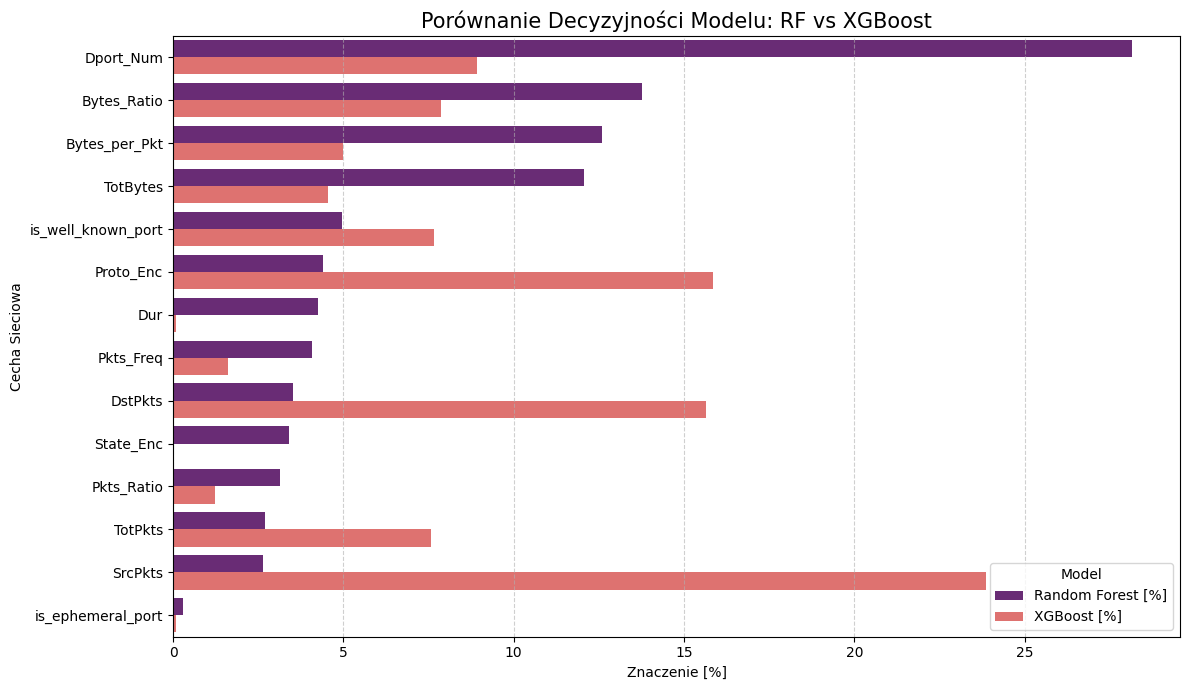


[*] Analiza odrzutów na surowych danych testowych (Zero-Day)...


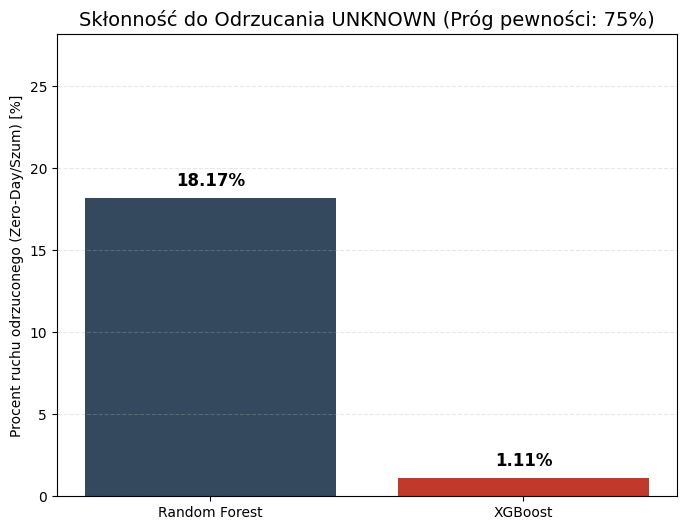

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import glob
import os

print("="*80)
print(">>> NOTATNIK 05: PORÓWNANIE MODELI I ANALIZA WAŻNOŚCI CECH <<<")
print("="*80)

output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)

# ==========================================
# 1. WCZYTANIE DANYCH I "SNAJPER"
# ==========================================
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ml_ready.csv', low_memory=False)

# Wyrzucamy szum i rzadkie anomalie - modele mają być "snajperami" na czystych kampaniach
classes_to_drop = ['Background Noise', 'Rare / Minor Anomalies']
df_train_raw = df_train_raw[~df_train_raw['Refined_Label'].isin(classes_to_drop)].copy()

# ==========================================
# 2. DEFINICJA CECH (Ostateczna, pełna lista!)
# ==========================================
FEATURES = [
    'Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
    'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio', 
    'is_well_known_port', 'is_ephemeral_port',
    'Proto_Enc', 'State_Enc', 'Dport_Num'
]

known_protos = {p: i for i, p in enumerate(df_train_raw['Proto'].astype(str).unique())}
known_states = {s: i for i, s in enumerate(df_train_raw['State'].astype(str).unique())}

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)
def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

# --- Przygotowanie Złotego Standardu (Train) ---
# Uwaga: df_train_raw ma już logarytmy i wyliczone Bytes_Ratio z Notatnika 01!
df_train = df_train_raw.copy()
df_train['Proto_Enc'] = df_train['Proto'].apply(lambda x: safe_encode(x, known_protos))
df_train['State_Enc'] = df_train['State'].apply(lambda x: safe_encode(x, known_states))
df_train['Dport_Num'] = df_train['Dport'].apply(safe_port)

X_train = df_train[FEATURES].fillna(0)

# Etykiety
y_train_rf = df_train['Refined_Label']
le_target = LabelEncoder()
y_train_xgb = le_target.fit_transform(df_train['Refined_Label'])
weights = compute_sample_weight(class_weight='balanced', y=y_train_xgb)

# ==========================================
# 3. TRENING OBU MODELI
# ==========================================
print("[*] Trenowanie modelu Random Forest...")
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', max_features='sqrt', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_rf)

print("[*] Trenowanie modelu XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, tree_method='hist', random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_xgb, sample_weight=weights)

# ==========================================
# 4. WYKRES 1: FEATURE IMPORTANCE
# ==========================================
rf_imp_vals = rf.feature_importances_ * 100
xgb_imp_vals = xgb_model.feature_importances_ * 100

df_comparison_table = pd.DataFrame({
    'Cecha Sieciowa': FEATURES,
    'Random Forest [%]': rf_imp_vals,
    'XGBoost [%]': xgb_imp_vals
})

df_comparison_table = df_comparison_table.sort_values(by='Random Forest [%]', ascending=False)

print("\n" + "="*80)
print(f"{'RANKING WAŻNOŚCI CECH (PROCENTOWY)':^80}")
print("="*80)
print(df_comparison_table.to_string(index=False, float_format="%.2f"))
print("="*80)

df_imp_plot = df_comparison_table.melt(id_vars='Cecha Sieciowa', var_name='Model', value_name='Znaczenie [%]')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_imp_plot, x='Znaczenie [%]', y='Cecha Sieciowa', hue='Model', palette='magma')
plt.title('Porównanie Decyzyjności Modelu: RF vs XGBoost', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '11_feature_importance_final.png'), dpi=300)
plt.show()

# ==========================================
# 5. WYKRES 2: ODRZUTY UNKNOWN (Z PRAWIDŁOWĄ FIZYKĄ TESTOWĄ!)
# ==========================================
print("\n[*] Analiza odrzutów na surowych danych testowych (Zero-Day)...")
test_files = glob.glob('../dane/testowe/*.csv')
df_test_raw = pd.concat([pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in test_files], ignore_index=True)

# PANCERNA FUNKCJA DLA DANYCH TESTOWYCH
def prepare_future_logs(df_input):
    df = df_input.copy()
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes', 'DstBytes']:
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
        
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    df['Bytes_Ratio']   = df.get('SrcBytes', 0) / (df.get('DstBytes', 0) + 1e-6)

    df['Dport_Num'] = df.get('Dport', 0).apply(safe_port)
    df['is_well_known_port'] = ((df['Dport_Num'] > 0) & (df['Dport_Num'] <= 1024)).astype(int)
    df['is_ephemeral_port'] = (df['Dport_Num'] >= 49152).astype(int)

    # MUST LOG TRANSFORM!
    cols_to_log = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio']
    for col in cols_to_log:
        df[col] = np.log1p(df[col].clip(lower=0))

    df['Proto_Enc'] = df.get('Proto', '').astype(str).apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df.get('State', '').astype(str).apply(lambda x: safe_encode(x, known_states))
    
    for f in FEATURES:
        if f not in df.columns: df[f] = 0
    return df[FEATURES].fillna(0)

X_new = prepare_future_logs(df_test_raw)
THRESHOLD = 0.75

rf_probs = np.max(rf.predict_proba(X_new), axis=1)
xgb_probs = np.max(xgb_model.predict_proba(X_new), axis=1)

rf_unk = np.mean(rf_probs < THRESHOLD) * 100
xgb_unk = np.mean(xgb_probs < THRESHOLD) * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(['Random Forest', 'XGBoost'], [rf_unk, xgb_unk], color=['#34495e', '#c0392b'])
plt.title(f'Skłonność do Odrzucania UNKNOWN (Próg pewności: {int(THRESHOLD*100)}%)', fontsize=14)
plt.ylabel('Procent ruchu odrzuconego (Zero-Day/Szum) [%]')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, max(rf_unk, xgb_unk) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig(os.path.join(output_dir, '12_unknown_rejection_final.png'), dpi=300)
plt.show()